In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [2]:
train = pd.read_csv("train.csv")

In [3]:
train.head()

,id,time,0,1,2,3,4,5,6,7,...,581,582,583,584,585,586,587,588,589,target
0,1198,2008-09-30 15:26:00,3075.32,2491.07,2185.1000,1201.0491,0.7821,100.0,105.8489,0.1208,...,NaN,0.4974,0.0128,0.0033,2.5767,0.0223,0.0105,0.0034,47.0690,-1
1,436,2008-08-23 05:58:00,3071.58,2489.47,2217.3777,1425.1041,1.7585,100.0,106.2556,0.1200,...,16.6695,0.5004,0.0316,0.0066,6.3183,0.0329,0.0055,0.0022,16.6695,-1
2,635,2008-01-09 20:51:00,3017.53,2524.09,2201.0667,880.2317,1.4148,100.0,106.5478,0.1211,...,NaN,0.4998,0.0097,0.0026,1.9495,0.0328,0.0235,0.0068,71.5333,-1
3,996,2008-09-21 19:19:00,2901.62,2569.45,2223.9000,1745.3724,1.9974,100.0,96.7567,0.1241,...,NaN,0.5004,0.0174,0.0034,3.4771,0.0200,0.0205,0.0061,102.5241,-1
4,782,2008-11-09 07:43:00,2982.59,2466.86,2117.5889,894.0996,1.4330,100.0,106.4944,0.1253,...,NaN,0.4986,0.0172,0.0038,3.4561,0.0373,0.0079,0.0030,21.0599,-1


In [4]:
train.shape

(1253, 593)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Columns: 593 entries, id to target
dtypes: float64(590), int64(2), object(1)
memory usage: 5.7+ MB


In [6]:
train.describe()

,id,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,target
count,1253.000000,1248.000000,1248.000000,1240.000000,1240.000000,1240.000000,1240.0,1240.000000,1245.000000,1251.000000,...,485.000000,1252.000000,1252.000000,1252.000000,1252.000000,1252.000000,1252.000000,1252.000000,1252.000000,1253.000000
mean,775.620910,3014.207228,2496.611378,2200.151328,1387.511151,3.124149,100.0,101.240427,0.121980,1.464348,...,95.981681,0.499997,0.015460,0.003879,3.098152,0.021659,0.016391,0.005255,98.443809,-0.867518
std,450.690458,73.029160,80.102790,29.445513,431.115520,44.594150,0.0,6.221999,0.007982,0.073735,...,83.330564,0.003449,0.019043,0.004133,3.969051,0.012508,0.008499,0.002758,93.163788,0.497604
min,0.000000,2743.240000,2162.870000,2060.660000,711.025800,0.681500,100.0,82.131100,0.000000,1.191000,...,0.000000,0.477800,0.006500,0.002000,1.284500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,386.000000,2965.715000,2454.682500,2181.155500,1080.498500,1.016000,100.0,98.113300,0.121100,1.412100,...,45.370100,0.497800,0.011600,0.003100,2.309350,0.013700,0.010700,0.003400,44.096100,-1.000000
50%,773.000000,3011.405000,2500.220000,2200.955600,1283.436800,1.316800,100.0,101.611100,0.122400,1.463600,...,71.084200,0.500000,0.013700,0.003600,2.742900,0.020700,0.014800,0.004600,71.533300,-1.000000
75%,1161.000000,3056.310000,2539.595000,2218.055500,1588.509000,1.529100,100.0,104.626700,0.123800,1.518950,...,115.100500,0.502200,0.016400,0.004100,3.281175,0.027700,0.020300,0.006400,114.415300,-1.000000
max,1566.000000,3356.350000,2846.440000,2315.266700,3715.041700,1112.160000,100.0,129.252200,0.128600,1.656400,...,706.824000,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


In [7]:
train['target'].value_counts()

target
-1    1170
 1      83
Name: count, dtype: int64

In [8]:
train.isnull().sum()

id         0
time       0
0          5
1          5
2         13
          ..
586        1
587        1
588        1
589        1
target     0
Length: 593, dtype: int64

In [9]:
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns
train[numeric_cols] = train[numeric_cols].fillna(train[numeric_cols].mean())

In [10]:
print(train.isnull().sum().sum())

0


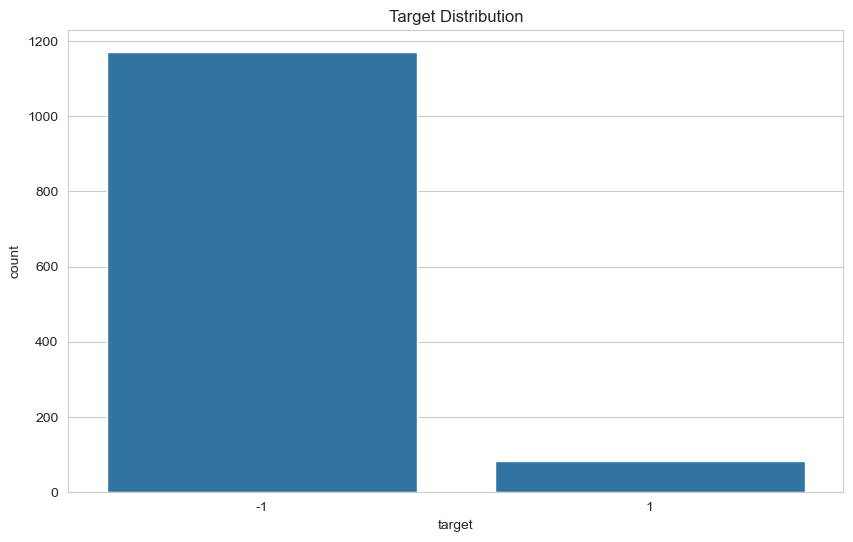

In [11]:
sns.countplot(x='target', data=train)
plt.title('Target Distribution')
plt.show()

In [12]:
print(train.duplicated().sum())

0


In [13]:
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns[:-1]
total_outliers = 0
for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((train[col] < Q1 - 1.5*IQR)  | (train[col] > Q3 + 1.5*IQR)).sum()
    total_outliers += outliers

print(f"Total Outliers: {total_outliers}")

Total Outliers: 28081


# EDA (Exploratory Data Analysis)

target
-1    1170
 1      83
Name: count, dtype: int64


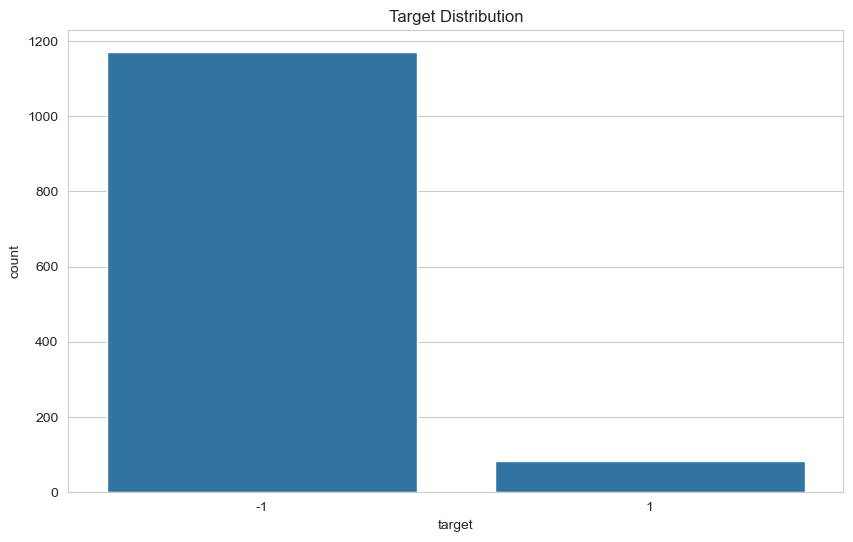

In [14]:
print(train['target'].value_counts())
sns.countplot(x='target', data=train)
plt.title('Target Distribution')
plt.show()

In [15]:
print("Negative Class (-1) Statistics:")
print(train[train['target'] == -1].describe().round(2))

print("\nPositive Class (1) Statistics:")
print(train[train['target'] == 1].describe().round(2))

Negative Class (-1) Statistics:
            id        0        1        2        3        4       5        6  \
count  1170.00  1170.00  1170.00  1170.00  1170.00  1170.00  1170.0  1170.00   
mean    786.33  3014.61  2496.19  2199.96  1388.41     3.25   100.0   101.22   
std     445.64    71.49    80.53    29.06   434.23    45.91     0.0     6.26   
min       0.00  2743.24  2162.87  2060.66   711.03     0.68   100.0    82.13   
25%     410.25  2968.78  2453.60  2181.81  1081.63     1.02   100.0    98.12   
50%     783.50  3012.56  2499.10  2200.22  1283.44     1.32   100.0   101.54   
75%    1160.75  3056.37  2539.59  2217.85  1586.95     1.54   100.0   104.63   
max    1566.00  3356.35  2846.44  2315.27  3715.04  1112.16   100.0   129.25   

             7        8  ...      581      582      583     584      585  \
count  1170.00  1170.00  ...  1170.00  1170.00  1170.00  1170.0  1170.00   
mean      0.12     1.46  ...    96.16     0.50     0.02     0.0     3.10   
std       0.01     

# Feature Engineering

In [16]:
from sklearn.preprocessing import StandardScaler

numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns[:-1]

scaler = StandardScaler()
train_scaled = train.copy()
train_scaled[numeric_cols] = scaler.fit_transform(train[numeric_cols])

print("Scaled data:")
print(train_scaled.head())

Scaled data:
         id                 time         0         1         2         3  \
0  0.937556  2008-09-30 15:26:00  0.838838 -0.069345 -0.514038 -0.434947   
1 -0.753858  2008-08-23 05:58:00  0.787502 -0.089367  0.588321  0.087691   
2 -0.312137  2008-01-09 20:51:00  0.045609  0.343866  0.031262 -1.183296   
3  0.489176  2008-09-21 19:19:00 -1.545379  0.911499  0.811073  0.834759   
4  0.014160  2008-11-09 07:43:00 -0.433980 -0.372307 -2.819702 -1.150948   

          4    5         6         7  ...       581       582       583  \
0 -0.052815  0.0  0.744847 -0.148371  ...  0.000000 -0.753457 -0.139800   
1 -0.030796  0.0  0.810580 -0.248961  ... -1.531399  0.117013  0.848206   
2 -0.038547  0.0  0.857807 -0.110649  ...  0.000000 -0.057081 -0.302716   
3 -0.025409  0.0 -0.724685  0.266564  ...  0.000000  0.117013  0.101946   
4 -0.038137  0.0  0.849176  0.417450  ...  0.000000 -0.405269  0.091436   

        584       585       586       587       588       589  target  
0 -0.14

# Feature Selection

In [17]:
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()[2:-1]

corr_with_target = train_scaled[numeric_cols].corrwith(train_scaled['target']).sort_values(ascending=False)

print("Top 10 Features:")
print(corr_with_target.head(10))

Top 10 Features:
103    0.172411
510    0.143689
59     0.125671
348    0.110711
129    0.108328
431    0.105501
64     0.103877
21     0.099353
430    0.092794
434    0.092334
dtype: float64


# PCA Principal Component Analysis

In [18]:
from sklearn.decomposition import PCA

pca = PCA()
train_pca = pca.fit_transform(train_scaled[numeric_cols])

print("Explained Variance Ratio (First 10):")
print(pca.explained_variance_ratio_[:10])

cumsum = pca.explained_variance_ratio_.cumsum()
print(f"\n95% variance components: {(cumsum >= 0.95).argmax() + 1}")

Explained Variance Ratio (First 10):
[0.05734525 0.03603866 0.02873889 0.02546907 0.0225387  0.02126298
 0.02026992 0.01897747 0.01827288 0.01648222]

95% variance components: 166


# Train / Test Split

In [19]:
from sklearn.model_selection import train_test_split

X = train_scaled[numeric_cols]
y = train_scaled['target']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=42, stratify=y)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"\nTrain target distribution:")
print(y_train.value_counts())

Train shape: (1211, 589)
Test shape: (42, 589)

Train target distribution:
target
-1    1131
 1      80
Name: count, dtype: int64


# Baseline Model

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline = LogisticRegression(random_state=42, max_iter=1000)
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

print("Baseline Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred): .4f} ")
print(f"Precision: {precision_score(y_test, y_pred): .4f}")
print(f"Recall: {recall_score(y_test, y_pred): .4f}")
print(f"F1-Score: {f1_score(y_test, y_pred): .4f}")

Baseline Model Performance:
Accuracy:  0.8571 
Precision:  0.2857
Recall:  0.6667
F1-Score:  0.4000


# Multiple ML Models

In [21]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    print(f"{name}: Acc={results[name]['Accuracy']: .4f}, F1={results[name]['F1-Score']: .4f}")

Logistic Regression: Acc= 0.8571, F1= 0.4000
Random Forest: Acc= 0.9524, F1= 0.5000
Gradient Boosting: Acc= 0.9286, F1= 0.4000
SVM: Acc= 0.9286, F1= 0.0000


# Imbalanced Classification

In [22]:
from imblearn.over_sampling import SMOTE

# SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f": {y_train.value_counts().to_dict()}")
print(f": {y_train_smote.value_counts().to_dict()}")

: {-1: 1131, 1: 80}
: {-1: 1131, 1: 1131}


# Cross-Validation

In [23]:
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

cv_scores = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=5, scoring='f1')

print("Cross-Validation F1-Scores:")
print(cv_scores)
print(f"\nMean CV Score: {cv_scores.mean(): .4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

Cross-Validation F1-Scores:
[0.98214286 0.99111111 0.99779249 0.99559471 0.99779249]

Mean CV Score:  0.9929
Std Dev: 0.0059


# Hyperpararneter Tuning

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best F1-Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"\nTest F1-Score: {f1_score(y_test, y_pred):.4f}")

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-Score: 0.9929

Test F1-Score: 0.0000


# SHAP (Explainability)

Top 10 Important Features:
    Feature  Importance
94       95    0.026529
212     213    0.017747
58       59    0.016586
350     351    0.014828
129     130    0.012873
32       33    0.012056
30       31    0.011432
102     103    0.011111
518     519    0.010978
432     433    0.010947


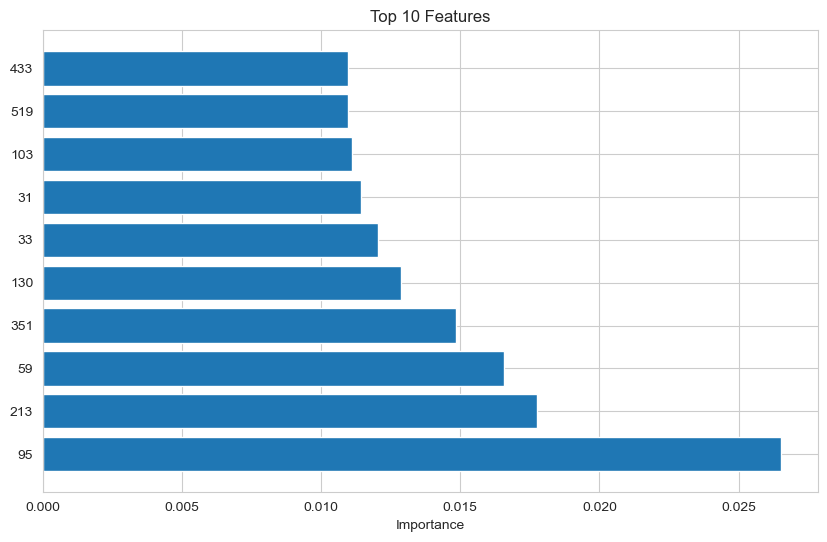

In [25]:
import numpy as np

importances = best_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['Feature'], feature_importance.head(10)['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features')
plt.show()

In [26]:
final_model = best_model

y_pred_final = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("="*50)
print("FINAL MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

FINAL MODEL PERFORMANCE
Accuracy: 0.9286
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.8547

Confusion Matrix:
[[39  0]
 [ 3  0]]

Classification Report:
              precision    recall  f1-score   support

          -1       0.93      1.00      0.96        39
           1       0.00      0.00      0.00         3

    accuracy                           0.93        42
   macro avg       0.46      0.50      0.48        42
weighted avg       0.86      0.93      0.89        42



In [27]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

y_pred_proba = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test ROC-AUC Score: {roc_auc:.4f}")

Test ROC-AUC Score: 0.8547


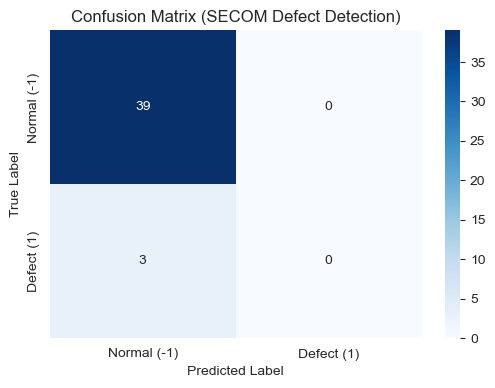

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (-1)', 'Defect (1)'], 
            yticklabels=['Normal (-1)', 'Defect (1)'])
plt.title('Confusion Matrix (SECOM Defect Detection)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

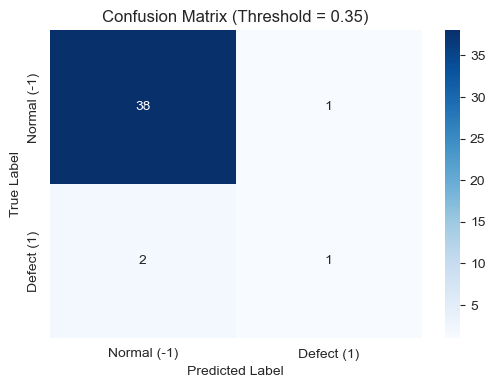

In [29]:
custom_threshold = 0.35
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

if -1 in y_test.values:
    y_pred_custom = np.where(y_pred_custom == 1, 1, -1)

cm_new = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (-1)', 'Defect (1)'], 
            yticklabels=['Normal (-1)', 'Defect (1)'])
plt.title(f'Confusion Matrix (Threshold = {custom_threshold})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()